<a href="https://colab.research.google.com/github/OJB-Quantum/Generative-Layout-Notebooks/blob/main/GDSTK_Square_Spiral.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Running this script will generate a square spiral, with a plot preview using matplotlib. Once the design is downloaded at the end, please be sure to add the ".gds" file extension when saving the file to your local machine.

In [1]:
!uv pip install gdstk

Using Python 3.13.15 environment at: /usr
Resolved 2 packages in 388ms
Prepared 1 package in 84ms
Installed 1 package in 1ms
 + gdstk==1.0.1


GDSTK version: 1.0.1
GDSII file: /content/square_spiral.gds
Preview file: /content/square_spiral_preview.png
Turns: 10
Centerline length: 4200.000 um
Trace width: 1.000 um
Centerline pitch: 10.000 um
Edge-to-edge gap: 9.000 um


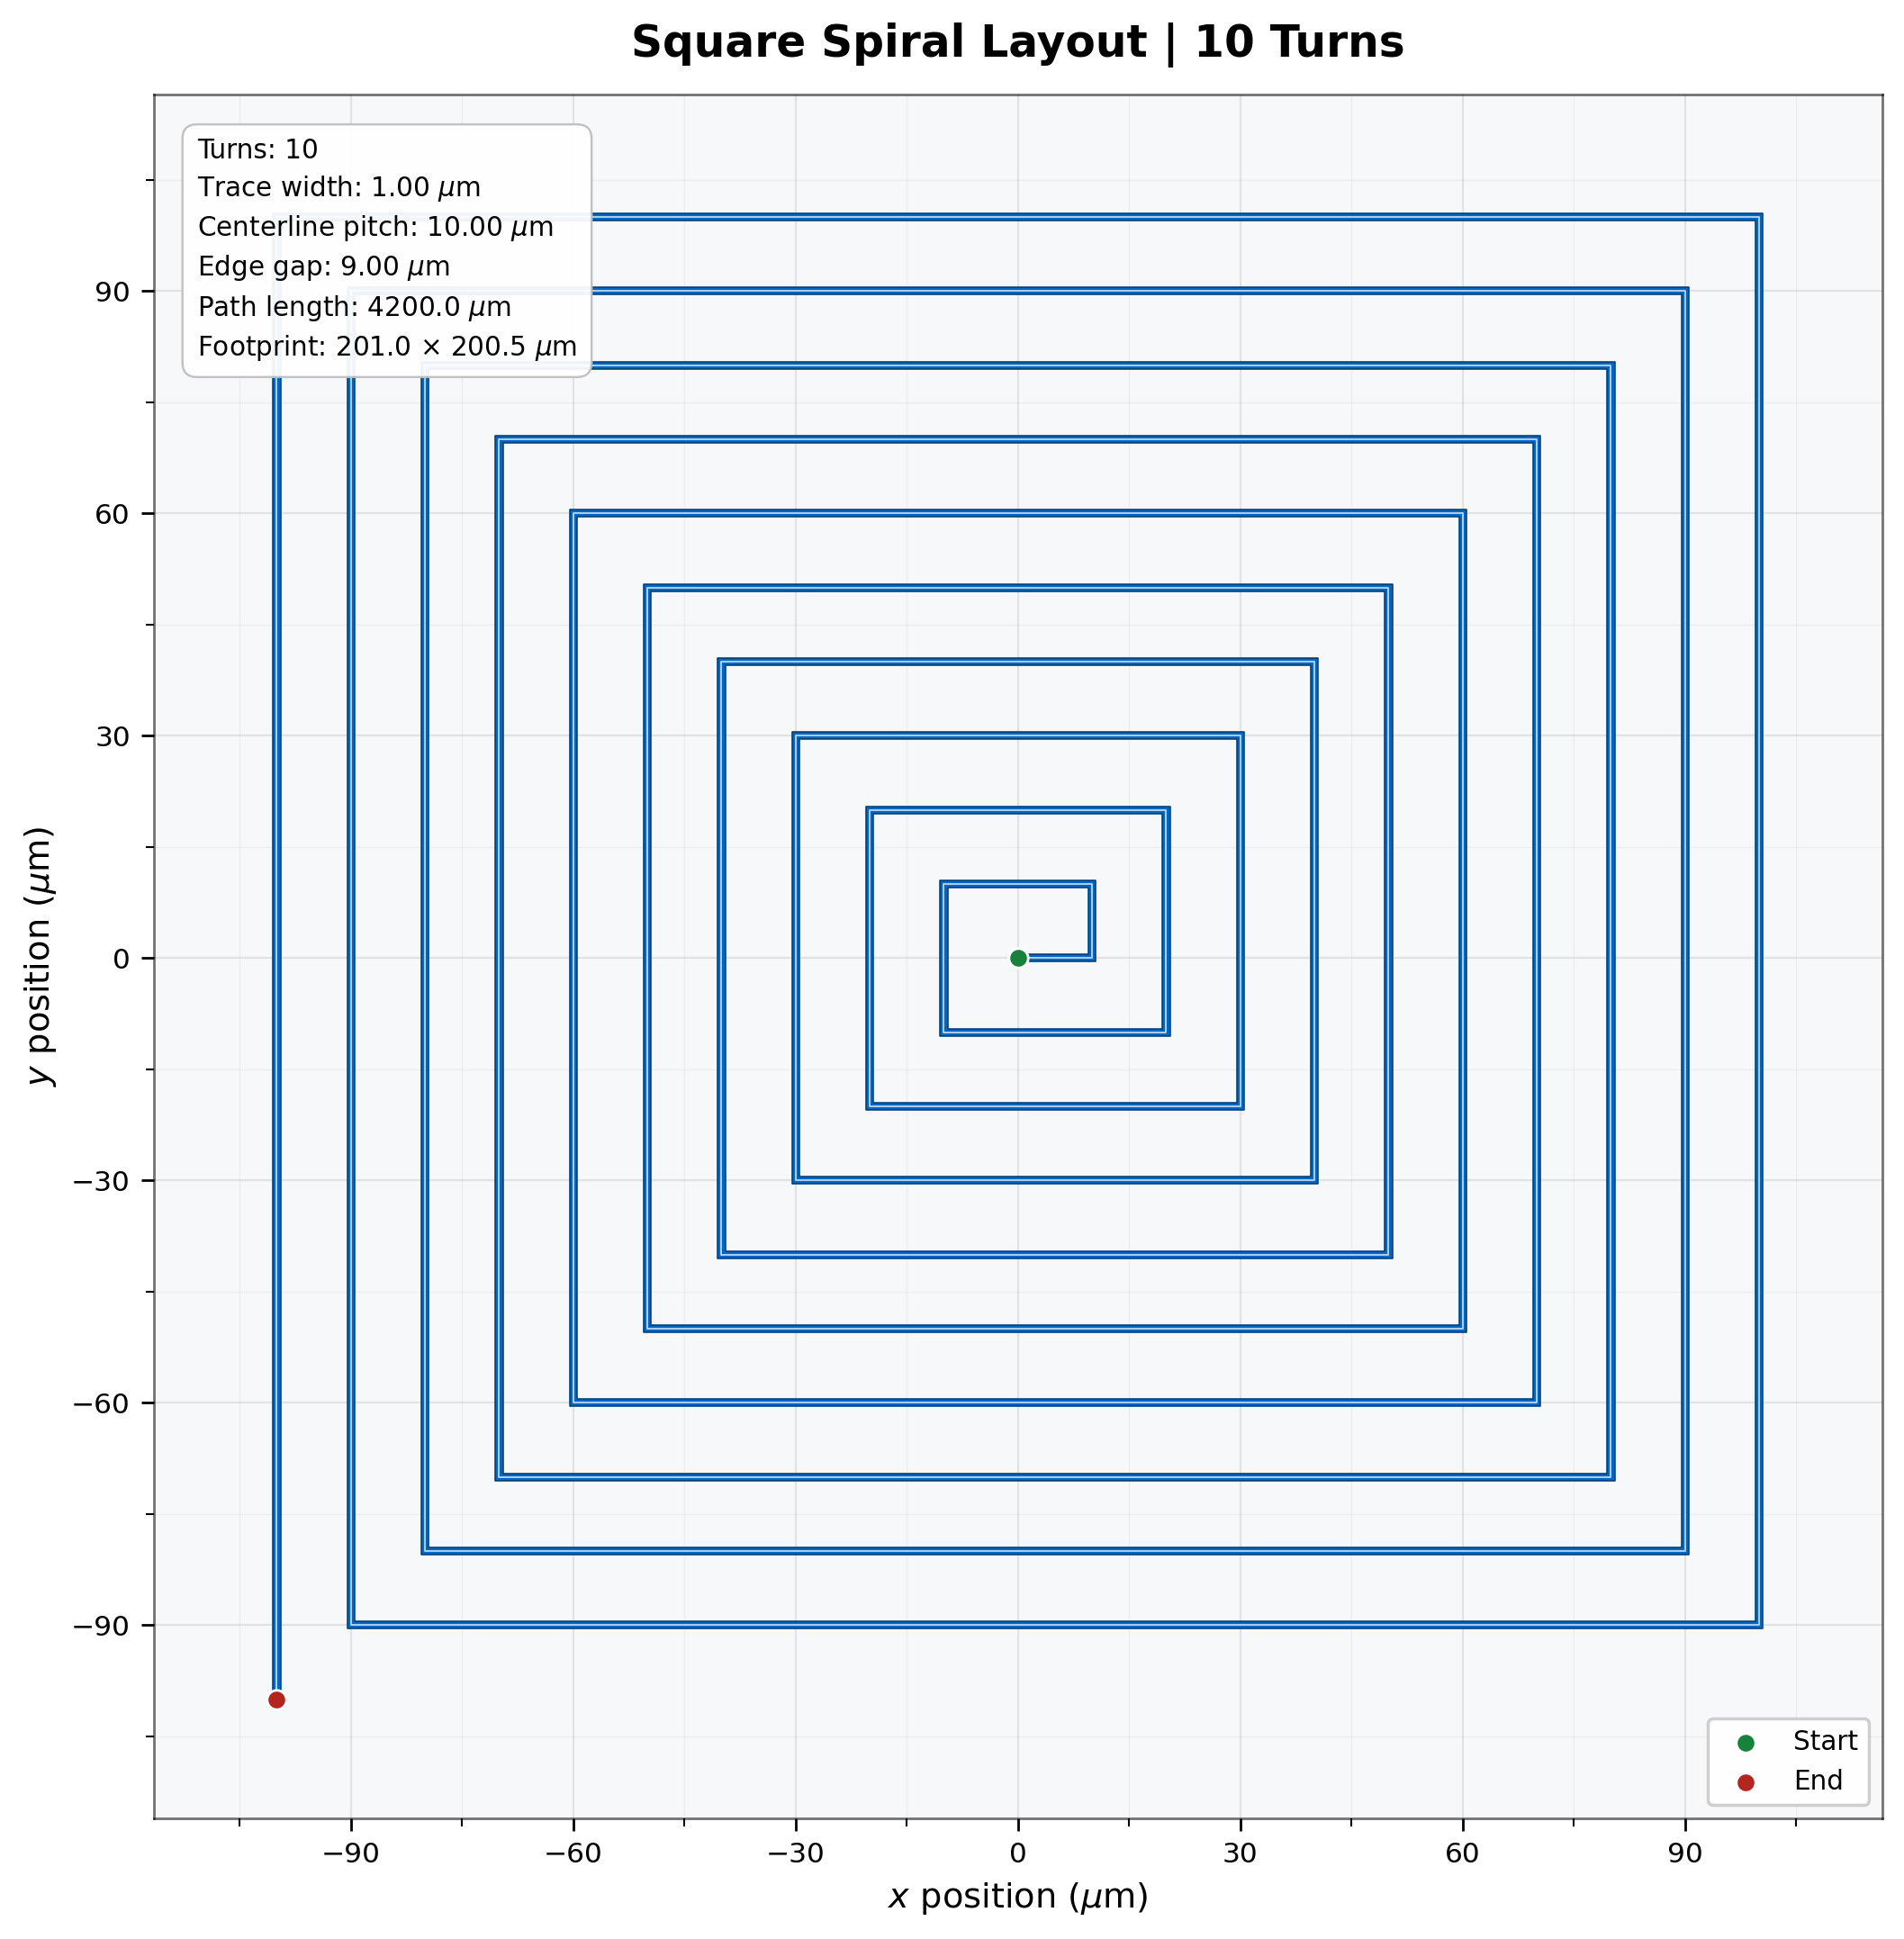

In [2]:
"""Generate, export, and visualize a square-spiral GDSTK layout.

The script constructs a square spiral from an orthogonal centerline, converts
the GDSTK FlexPath to polygons for visualization, exports the geometry as a
GDSII file, and renders a publication-quality Matplotlib preview.

All geometric dimensions are expressed in micrometers.
"""

import pathlib

import gdstk
from matplotlib import collections
from matplotlib import ticker
import matplotlib.pyplot as plt
import numpy as np


# =============================================================================
# Control knobs - spiral geometry
# =============================================================================

NUM_TURNS = 10
STEP_UM = 10.0
PATH_WIDTH_UM = 1.0

START_X_UM = 0.0
START_Y_UM = 0.0

GDS_LAYER = 1
GDS_DATATYPE = 0

# Minimum allowed edge-to-edge spacing between neighboring spiral traces.
MIN_EDGE_GAP_UM = 1.0


# =============================================================================
# Control knobs - GDSII output
# =============================================================================

OUTPUT_GDS_PATH = pathlib.Path("square_spiral.gds")

LIBRARY_NAME = "SQUARE_SPIRAL_LIBRARY"
CELL_NAME = "SQUARE_SPIRAL"

# 1 layout unit = 1 micrometer.
GDS_UNIT_M = 1.0e-6

# 1 nm coordinate precision.
GDS_PRECISION_M = 1.0e-9


# =============================================================================
# Control knobs - plot
# =============================================================================

FIGURE_WIDTH_IN = 8.5
FIGURE_HEIGHT_IN = 8.5
PLOT_DPI = 250

GEOMETRY_COLOR = "#0067C5"
GEOMETRY_EDGE_COLOR = "#003D73"
CENTERLINE_COLOR = "#FFFFFF"

START_MARKER_COLOR = "#17823B"
END_MARKER_COLOR = "#B3261E"

FIGURE_BACKGROUND_COLOR = "#FFFFFF"
AXES_BACKGROUND_COLOR = "#F7F8FA"

GEOMETRY_EDGE_WIDTH = 0.45
CENTERLINE_WIDTH = 0.55
CENTERLINE_ALPHA = 0.70

SHOW_CENTERLINE = True
SHOW_ENDPOINTS = True
SHOW_MINOR_GRID = True
SHOW_GEOMETRY_INFO = True

MARKER_SIZE = 38.0

MAJOR_GRID_ALPHA = 0.30
MINOR_GRID_ALPHA = 0.14

VIEW_PADDING_FRACTION = 0.08

SAVE_PLOT = True
OUTPUT_PLOT_PATH = pathlib.Path("square_spiral_preview.png")


# =============================================================================
# Geometry construction
# =============================================================================


def validate_parameters() -> None:
    """Validate the user-adjustable geometry parameters.

    Raises:
        ValueError: If a geometric parameter would produce invalid geometry.
    """
    if NUM_TURNS < 1:
        raise ValueError("NUM_TURNS must be at least 1.")

    if STEP_UM <= 0.0:
        raise ValueError("STEP_UM must be greater than 0.")

    if PATH_WIDTH_UM <= 0.0:
        raise ValueError("PATH_WIDTH_UM must be greater than 0.")

    edge_gap_um = STEP_UM - PATH_WIDTH_UM

    if edge_gap_um < MIN_EDGE_GAP_UM:
        raise ValueError(
            "STEP_UM produces insufficient trace spacing. "
            f"Calculated edge gap = {edge_gap_um:.3f} um, "
            f"minimum = {MIN_EDGE_GAP_UM:.3f} um."
        )


def generate_square_spiral_spine() -> np.ndarray:
    """Generate the square-spiral centerline coordinates.

    Each requested turn corresponds to one complete 360-degree revolution,
    represented by four orthogonal segments. Segment lengths increase after
    every pair of segments to produce uniform centerline spacing.

    Returns:
        An array with shape ``(N, 2)`` containing the centerline coordinates
        in micrometers.
    """
    directions = np.array(
        [
            [1.0, 0.0],
            [0.0, 1.0],
            [-1.0, 0.0],
            [0.0, -1.0],
        ],
        dtype=float,
    )

    current_position = np.array(
        [START_X_UM, START_Y_UM],
        dtype=float,
    )

    points = [current_position.copy()]
    segment_length_um = STEP_UM
    num_segments = 4 * NUM_TURNS

    for segment_index in range(num_segments):
        direction = directions[segment_index % len(directions)]

        current_position = (
            current_position + direction * segment_length_um
        )
        points.append(current_position.copy())

        if (segment_index + 1) % 2 == 0:
            segment_length_um += STEP_UM

    return np.asarray(points)


def build_spiral_path(spine: np.ndarray) -> gdstk.FlexPath:
    """Construct a GDSTK FlexPath from the spiral centerline.

    Args:
        spine: Centerline coordinates with shape ``(N, 2)``.

    Returns:
        The constructed GDSTK FlexPath.
    """
    return gdstk.FlexPath(
        spine,
        width=PATH_WIDTH_UM,
        ends="flush",
        layer=GDS_LAYER,
        datatype=GDS_DATATYPE,
    )


def build_library(path: gdstk.FlexPath) -> gdstk.Library:
    """Place the spiral into a GDSTK library.

    Args:
        path: Spiral path to add to the layout.

    Returns:
        A GDSTK library containing the square spiral.
    """
    library = gdstk.Library(
        name=LIBRARY_NAME,
        unit=GDS_UNIT_M,
        precision=GDS_PRECISION_M,
    )

    cell = library.new_cell(CELL_NAME)
    cell.add(path)

    return library


# =============================================================================
# Geometry analysis
# =============================================================================


def calculate_centerline_length(spine: np.ndarray) -> float:
    """Calculate the total centerline length.

    Args:
        spine: Centerline coordinates in micrometers.

    Returns:
        Total centerline length in micrometers.
    """
    segment_vectors = np.diff(spine, axis=0)
    segment_lengths = np.linalg.norm(segment_vectors, axis=1)

    return float(np.sum(segment_lengths))


def calculate_polygon_bounds(
    polygons: list[gdstk.Polygon],
) -> tuple[float, float, float, float]:
    """Calculate the bounding box enclosing all polygons.

    Args:
        polygons: GDSTK polygons forming the spiral.

    Returns:
        Minimum x, maximum x, minimum y, and maximum y coordinates.

    Raises:
        ValueError: If the polygon collection is empty.
    """
    if not polygons:
        raise ValueError("No polygons were generated from the spiral path.")

    all_points = np.vstack([polygon.points for polygon in polygons])

    x_min = float(np.min(all_points[:, 0]))
    x_max = float(np.max(all_points[:, 0]))
    y_min = float(np.min(all_points[:, 1]))
    y_max = float(np.max(all_points[:, 1]))

    return x_min, x_max, y_min, y_max


# =============================================================================
# Visualization
# =============================================================================


def configure_axes(
    ax: plt.Axes,
    bounds: tuple[float, float, float, float],
) -> None:
    """Configure plot limits, ticks, grids, and labels.

    Args:
        ax: Matplotlib axes to configure.
        bounds: Geometry bounds as ``xmin, xmax, ymin, ymax``.
    """
    x_min, x_max, y_min, y_max = bounds

    x_span = x_max - x_min
    y_span = y_max - y_min

    largest_span = max(x_span, y_span)
    padding = largest_span * VIEW_PADDING_FRACTION

    ax.set_xlim(x_min - padding, x_max + padding)
    ax.set_ylim(y_min - padding, y_max + padding)

    ax.set_aspect("equal", adjustable="box")
    ax.set_facecolor(AXES_BACKGROUND_COLOR)

    ax.set_xlabel(r"$x$ position ($\mu$m)", fontsize=11)
    ax.set_ylabel(r"$y$ position ($\mu$m)", fontsize=11)

    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=8))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=8))

    if SHOW_MINOR_GRID:
        ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
        ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))

    ax.grid(
        visible=True,
        which="major",
        linewidth=0.65,
        alpha=MAJOR_GRID_ALPHA,
    )

    if SHOW_MINOR_GRID:
        ax.grid(
            visible=True,
            which="minor",
            linewidth=0.40,
            alpha=MINOR_GRID_ALPHA,
        )

    ax.tick_params(
        axis="both",
        which="major",
        direction="out",
        length=4.0,
        width=0.8,
        labelsize=9,
    )

    ax.tick_params(
        axis="both",
        which="minor",
        direction="out",
        length=2.5,
        width=0.6,
    )

    for spine_object in ax.spines.values():
        spine_object.set_linewidth(0.8)
        spine_object.set_alpha(0.55)


def add_geometry_information(
    ax: plt.Axes,
    spine: np.ndarray,
    bounds: tuple[float, float, float, float],
) -> None:
    """Add compact geometric statistics to the plot.

    Args:
        ax: Matplotlib axes receiving the annotation.
        spine: Spiral centerline coordinates.
        bounds: Geometry bounding box.
    """
    x_min, x_max, y_min, y_max = bounds

    width_um = x_max - x_min
    height_um = y_max - y_min
    centerline_length_um = calculate_centerline_length(spine)
    edge_gap_um = STEP_UM - PATH_WIDTH_UM

    information = (
        f"Turns: {NUM_TURNS}\n"
        f"Trace width: {PATH_WIDTH_UM:.2f} $\\mu$m\n"
        f"Centerline pitch: {STEP_UM:.2f} $\\mu$m\n"
        f"Edge gap: {edge_gap_um:.2f} $\\mu$m\n"
        f"Path length: {centerline_length_um:.1f} $\\mu$m\n"
        f"Footprint: {width_um:.1f} × {height_um:.1f} $\\mu$m"
    )

    ax.text(
        0.025,
        0.975,
        information,
        transform=ax.transAxes,
        horizontalalignment="left",
        verticalalignment="top",
        fontsize=8.5,
        linespacing=1.45,
        bbox={
            "boxstyle": "round,pad=0.55",
            "facecolor": "white",
            "edgecolor": "0.75",
            "linewidth": 0.7,
            "alpha": 0.94,
        },
        zorder=10,
    )


def plot_spiral(
    path: gdstk.FlexPath,
    spine: np.ndarray,
) -> None:
    """Render the spiral as filled GDSTK polygons.

    Args:
        path: GDSTK path representing the spiral.
        spine: Centerline coordinates in micrometers.
    """
    polygons = path.to_polygons()
    bounds = calculate_polygon_bounds(polygons)

    vertices = [polygon.points for polygon in polygons]

    polygon_collection = collections.PolyCollection(
        vertices,
        facecolors=GEOMETRY_COLOR,
        edgecolors=GEOMETRY_EDGE_COLOR,
        linewidths=GEOMETRY_EDGE_WIDTH,
        antialiased=True,
        zorder=3,
    )

    figure, ax = plt.subplots(
        figsize=(FIGURE_WIDTH_IN, FIGURE_HEIGHT_IN),
        dpi=PLOT_DPI,
        constrained_layout=True,
    )

    figure.patch.set_facecolor(FIGURE_BACKGROUND_COLOR)
    ax.add_collection(polygon_collection)

    if SHOW_CENTERLINE:
        ax.plot(
            spine[:, 0],
            spine[:, 1],
            color=CENTERLINE_COLOR,
            linewidth=CENTERLINE_WIDTH,
            alpha=CENTERLINE_ALPHA,
            zorder=4,
        )

    if SHOW_ENDPOINTS:
        ax.scatter(
            spine[0, 0],
            spine[0, 1],
            s=MARKER_SIZE,
            color=START_MARKER_COLOR,
            edgecolor="white",
            linewidth=0.8,
            zorder=6,
            label="Start",
        )

        ax.scatter(
            spine[-1, 0],
            spine[-1, 1],
            s=MARKER_SIZE,
            color=END_MARKER_COLOR,
            edgecolor="white",
            linewidth=0.8,
            zorder=6,
            label="End",
        )

        ax.legend(
            loc="lower right",
            fontsize=8.5,
            frameon=True,
            framealpha=0.94,
        )

    configure_axes(ax, bounds)

    ax.set_title(
        f"Square Spiral Layout | {NUM_TURNS} Turns",
        fontsize=14,
        fontweight="semibold",
        pad=12,
    )

    if SHOW_GEOMETRY_INFO:
        add_geometry_information(ax, spine, bounds)

    if SAVE_PLOT:
        figure.savefig(
            OUTPUT_PLOT_PATH,
            dpi=PLOT_DPI,
            bbox_inches="tight",
            facecolor=figure.get_facecolor(),
        )

    plt.show()


# =============================================================================
# Program entry point
# =============================================================================


def main() -> None:
    """Generate, export, and visualize the square spiral."""
    validate_parameters()

    spine = generate_square_spiral_spine()
    path = build_spiral_path(spine)
    library = build_library(path)

    library.write_gds(OUTPUT_GDS_PATH)

    centerline_length_um = calculate_centerline_length(spine)
    edge_gap_um = STEP_UM - PATH_WIDTH_UM

    print(f"GDSTK version: {gdstk.__version__}")
    print(f"GDSII file: {OUTPUT_GDS_PATH.resolve()}")

    if SAVE_PLOT:
        print(f"Preview file: {OUTPUT_PLOT_PATH.resolve()}")

    print(f"Turns: {NUM_TURNS}")
    print(f"Centerline length: {centerline_length_um:.3f} um")
    print(f"Trace width: {PATH_WIDTH_UM:.3f} um")
    print(f"Centerline pitch: {STEP_UM:.3f} um")
    print(f"Edge-to-edge gap: {edge_gap_um:.3f} um")

    plot_spiral(path, spine)

if __name__ == "__main__":
    main()

In [3]:
from google.colab import files
files.download("square_spiral.gds")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>